### **Projeto 1 - Ciência de Dados**

*  **Nome**: Jansen Rodrigues de Avila
*  **Matrícula**: 2102410001

**Descrição Geral do Projeto**:

  Investigar a evolução dos óbitos, internações de dias de permanência dos casos de pneumonia ao longo dos anos no Rio Grande do Sul.



*   **Objetivos**
1. Análise de tendência temporal
2.   Análise Comparativa Normalizada
3.   Comunicação dos Resultados
4. Produção Cientifica

**- DÚVIDAS**




## **Carga de Dados**

**Morbidade Hospitalar do SUS - por local de residência - *Rio Grande do Sul***

  *   **Linha:** Ano processamento
  *   **Coluna:** Não ativa
  * **Conteúdo:** Internações/Dias de permanência/Óbitos


**Períodos**: Jan/2008 - Fev/2026
/ **Seleção**: X. Doenças do aparelho respiratório (Pneumonia)

In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import seaborn as sns

In [251]:
dataframe = pd.read_csv("https://raw.githubusercontent.com/janavila/data-science/refs/heads/main/datasets/doencResp_p1.txt", sep=";")
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Ano atendimento   21 non-null     object
 1   Internações       21 non-null     int64 
 2   Dias permanência  21 non-null     int64 
 3   Óbitos            21 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 804.0+ bytes


In [252]:
dataframe.head()

,Ano atendimento,Internações,Dias permanência,Óbitos
0,2007,2247,18611,135
1,2008,45610,298601,2891
2,2009,54643,352568,3778
3,2010,54573,349266,3824
4,2011,52055,338870,4058


In [253]:
dataframe.describe()

,Internações,Dias permanência,Óbitos
count,21.000000,2.100000e+01,21.000000
mean,78267.714286,5.325202e+05,8277.714286
std,171036.995508,1.163406e+06,18087.407020
min,2247.000000,1.802900e+04,135.000000
25%,44159.000000,2.988930e+05,4029.000000
50%,46109.000000,3.204430e+05,4827.000000
75%,50080.000000,3.388700e+05,5379.000000
max,821811.000000,5.591462e+06,86916.000000


In [254]:
# Removendo dados de 2007 e valor total no final.
dataframe = dataframe[dataframe['Ano atendimento'] != '2007']
dataframe = dataframe[dataframe['Ano atendimento'] != 'Total']
dataframe = dataframe[dataframe['Ano atendimento'] != '2026'] # Caso queira remover 2026

dataframe.head(n=18)

,Ano atendimento,Internações,Dias permanência,Óbitos
1,2008,45610,298601,2891
2,2009,54643,352568,3778
3,2010,54573,349266,3824
4,2011,52055,338870,4058
5,2012,49700,326536,4367
6,2013,52075,350172,4827
7,2014,48896,335505,4913
8,2015,48024,325545,4716
9,2016,50080,340075,5379
10,2017,46109,311835,5026


## **Preparação de Dados**


In [255]:
# Preparação dos anos de atendimento para INT.
anos = dataframe['Ano atendimento'].astype(int).to_numpy()
obitos = dataframe['Óbitos']
internacoes = dataframe['Internações']
permanencia = dataframe['Dias permanência']

X = sm.add_constant(anos) # X -> Anos (Soma a constante também para não começar em (0,0))
Y_1 = dataframe['Internações'].astype(int).values # Y_1 - Internações
Y_2 = dataframe['Óbitos'].astype(float).values # Y_2 - Óbitos
Y_3 = dataframe['Dias permanência'].astype(float).values # # Y_3 - Dias de Permanência

In [256]:
#plt.boxplot(obitos, tick_labels=["Total"])
#plt.boxplot(internacoes, tick_labels=["Total"])
#plt.boxplot(permanencia, tick_labels=["Total"])

## **Regressão Linear**
(Análise de Tendência Temporal)

In [257]:
slopes = [] # inclinação da reta (coeficiente angular)
interceptos = [] # constante - ponto onde a reta cruza o eixo vertical (Y)
p_values = [] # medida estatística da significância da tendência.
r2_adj = [] # coeficiente de determinação (quanto  o fator "tempo" explica a variação)
medias = [] # Medias aritmética
variaveis_nomes = [] # Para armazenar os nomes das variáveis

# Lista de variáveis para regressão
variaveis_para_regressao = [
    ("Internações", Y_1),
    ("Óbitos", Y_2),
    ("Dias permanência", Y_3)
]

# Realizando a regressão linear para cada variável
for nome_variavel, Y in variaveis_para_regressao:
    model = sm.OLS(Y, X).fit() # método dos Mínimos Quadrados Ordinários. Encontra a reta que minimiza a distância entre os pontos reais e tendência

    variaveis_nomes.append(nome_variavel)
    slopes.append(model.params[1]) # Coeficiente Angular.
    interceptos.append(model.params[0]) # Intercepto
    p_values.append(model.pvalues[1]) # P Valor (estatístico)
    r2_adj.append(model.rsquared_adj) # R quadrado
    medias.append(Y.mean()) # Média

slopes = np.array(slopes)
medias = np.array(medias)

razoes = slopes / medias # cálculo para tendência relativa (nesse caso, dá a mudança percentual média por ano em relação à média geral)

# Criando um DataFrame com os resultados de todas as regressões
resultadosDf = pd.DataFrame({
    "Variável": variaveis_nomes,
    "Coef_Angular": slopes,
    "Intercepto": interceptos,
    "p_valor": p_values,
    "R2_ajustado": r2_adj,
    "Media": medias,
    "Razao": razoes
})

resultadosDf.head()

,Variável,Coef_Angular,Intercepto,p_valor,R2_ajustado,Media,Razao
0,Internações,-877.24355,1.814334e+06,0.020401,0.248583,45372.277778,-0.019334
1,Óbitos,129.74097,-2.568268e+05,0.000134,0.584157,4795.833333,0.027053
2,Dias permanência,-3997.24871,8.369053e+06,0.091067,0.116098,308601.222222,-0.012953


## **Análise Comparativa Normalizada**
(Regressão Linear)

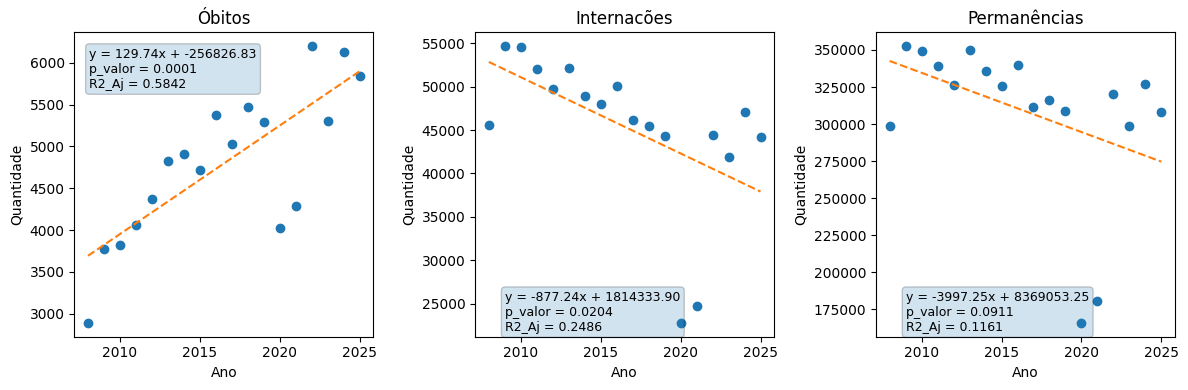

In [258]:
y_obitos = dataframe['Óbitos'].values.flatten()
y_internacoes = dataframe['Internações'].values.flatten()
y_permanencia = dataframe['Dias permanência'].values.flatten()

def trend(anos, y):
  model = LinearRegression()
  X = np.array(anos).reshape(-1, 1)
  model.fit(X, y)
  return model.predict(X)

obitos_pred = (anos, y_obitos)
internacoes_pred = (anos, y_internacoes)
permanencia_pred = (anos, y_permanencia)

# Gráfico de dispersão

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(anos.flatten(), y_obitos, 'o', label='Óbitos')
axes[0].plot(anos.flatten(), trend(anos, y_obitos), linestyle='--')
axes[0].set_title("Óbitos")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade")

c = resultadosDf.loc[1, 'Coef_Angular']
i = resultadosDf.loc[1, 'Intercepto']
p = resultadosDf.loc[1, 'p_valor']
r = resultadosDf.loc[1, 'R2_ajustado']

eq_obitos = f"y = {c:.2f}x + {i:.2f}\np_valor = {p:.4f}\nR2_Aj = {r:.4f}"
axes[0].text(
    0.05, 0.95, eq_obitos,
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.2))

axes[1].plot(anos.flatten(), y_internacoes, 'o', label='Óbitos')
axes[1].plot(anos.flatten(), trend(anos, y_internacoes), linestyle='--')
axes[1].set_title("Internacões")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Quantidade")

c = resultadosDf.loc[0, 'Coef_Angular']
i = resultadosDf.loc[0, 'Intercepto']
p = resultadosDf.loc[0, 'p_valor']
r = resultadosDf.loc[0, 'R2_ajustado']

eq_obitos = f"y = {c:.2f}x + {i:.2f}\np_valor = {p:.4f}\nR2_Aj = {r:.4f}"
axes[1].text(
    0.1, 0.01, eq_obitos,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", alpha=0.2))

axes[2].plot(anos.flatten(), y_permanencia, 'o', label='Óbitos')
axes[2].plot(anos.flatten(), trend(anos, y_permanencia), linestyle='--')
axes[2].set_title("Permanências")
axes[2].set_xlabel("Ano")
axes[2].set_ylabel("Quantidade")

c = resultadosDf.loc[2, 'Coef_Angular']
i = resultadosDf.loc[2, 'Intercepto']
p = resultadosDf.loc[2, 'p_valor']
r = resultadosDf.loc[2, 'R2_ajustado']

eq_obitos = f"y = {c:.2f}x + {i:.2f}\np_valor = {p:.4f}\nR2_Aj = {r:.4f}"
axes[2].text(
    0.1, 0.01, eq_obitos,
    transform=axes[2].transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", alpha=0.2))

plt.tight_layout()
plt.show()

### **Outras Analises**


1.   Taxa de Mortalidade por Internações
2.   Taxa de Internações por Dias de Permanência



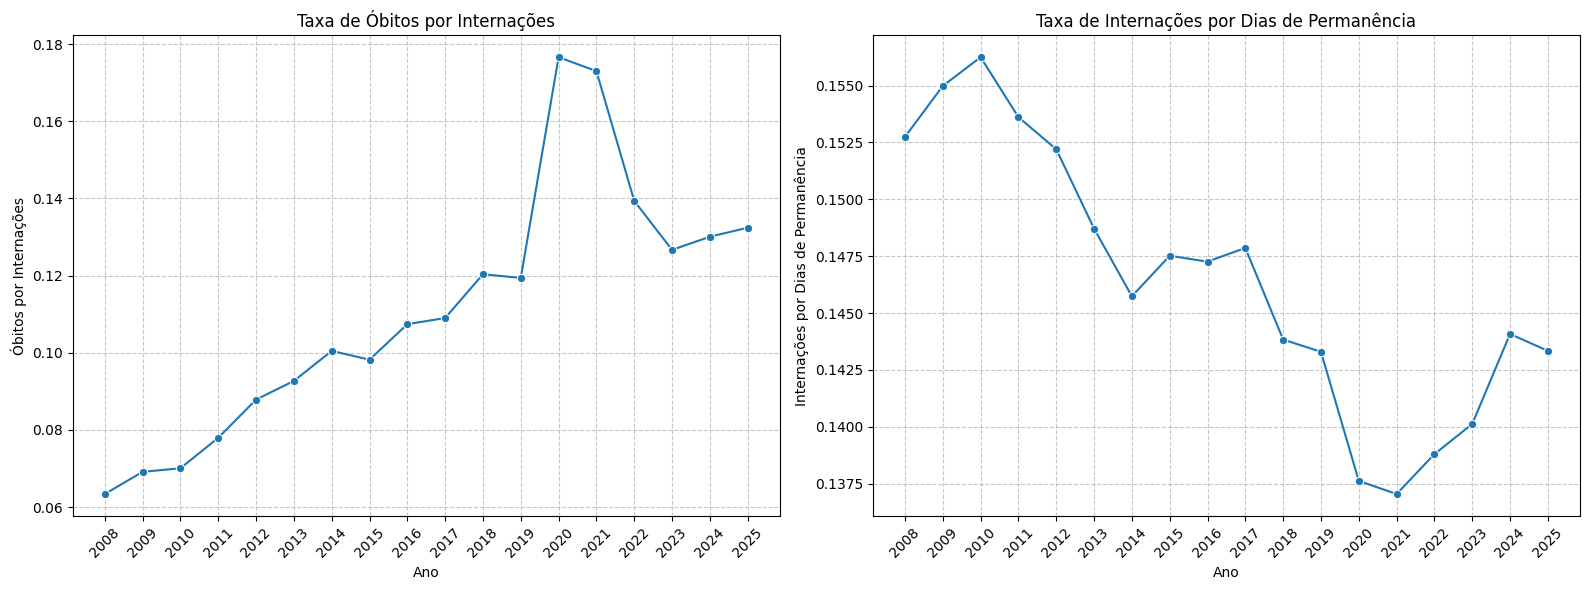

In [259]:
# Taxa de mortalidade por internações
dataframe['obitosInternacoes'] = dataframe['Óbitos'] / dataframe['Internações']
dataframe['internacoesPermanencia'] = dataframe['Internações'] / dataframe['Dias permanência']

# Criando a figura e os dois subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 linha, 2 colunas para os gráficos

# Gráfico para Taxa de Óbitos por Internações
sns.lineplot(x='Ano atendimento', y='obitosInternacoes', data=dataframe, marker='o', ax=axes[0])
axes[0].set_title('Taxa de Óbitos por Internações')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Óbitos por Internações')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico para Taxa de Internações por Dias de Permanência
sns.lineplot(x='Ano atendimento', y='internacoesPermanencia', data=dataframe, marker='o', ax=axes[1])
axes[1].set_title('Taxa de Internações por Dias de Permanência')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Internações por Dias de Permanência')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Resultados**

- As métricas foram realizadas utilizando como base o ano de atendimento, em função dos **dias de permanência**, **internações** e **óbitos** para a CID de doenças de problemas respiratório (*pneumonia*).

####**1. Análise de tendência temporal**

**Internações:**

- Há uma **diminuição** de **877 casos por ano** (arredondado)
- **$p-valor$**: 0,02 - chance de erro de **2%** e confiança de **98%**
- **$R^2$-ajustado**: 0,248583 - Tendência não é muito linear, ou seja, a queda não é totalmente definida pela passagem de ano **(24,8%)**
- **Média**: 45372 casos (arredondado)
- **Razão:** -0.019334 - Ou seja, porcentagem de diminuição anual de 1,9%

**Óbitos:**
- Há um **aumento** de **129 casos por ano** (arredondado)
- **$p-valor$**: 0,000134 - Confiança de **99,98%**
- **$R^2$-ajustado**: 0,584157 - 58,4% definido pela passagem de ano, ainda sendo afetado por outras causas externas (frio, gripes e etc)
- **Média**: 4796 casos (arredondado)
- **Razão:** 0,027053 - Ou seja, porcentagem de aumento anual de **2,7%**

**Dias de Permanência:**
- Há uma **diminuição** de **3997 dias por ano** (arredondado)
- **$p-valor$**: 0,091067 - Confiança de **91,06%**, não estatísticamente significativo pela regra dos 0,05, podendo ter possíveis oscilações com o tempo.
- **$R^2$-ajustado**: 0,116098 - 11,6% definido pela passagem de ano, ou seja, pouca significância.
- **Média**: 308601 casos (arredondado)
- **Razão:** -0,012953 - Porcentagem de diminuição anual de **1,29%**

####**2. Análise Comparativa Normalizada**

- Houve aumento de casos para todos os parametros de análisados em meados do fim da pandemia da COVID-19, a partir de 2022.
- Há uma diminuição gradual nas internações (1,9%), contudo, os dias de permanência (1,23%) não acompanha a diminuição. A tendência para dias de permanência não apresentou significância estatística ao nível de 5%. Ou seja, há menos internações mas maior período de permanência.
- A análise por ano não se torna tão efetiva para casos de pneumonia devido ao invernos rigorosos que podem causar muitos saltos por oscilações.
- Houve um grande salto de taxa de óbitos por internações em meados de 2022 (=~0,18), sendo que numa **média de 6 internações havia um possível óbito.**
- Diminuição do **volume** dos dias de permanência por internação nos anos de 2020 até 2023 devido aos períodos de pandêmia.


